# 💳 Prédiction de Défaut de Paiement (Credit Card Default)

## Objectif
Prédire si un client va faire **défaut de paiement** sur sa carte de crédit (classification binaire : 0 = pas de défaut, 1 = défaut).

In [ ]:
# Installation des librairies manquantes (exécuter une seule fois)
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

# Configuration reproductibilité
SEED = 42
np.random.seed(SEED)

print("✅ Imports terminés")

✅ Imports terminés


In [2]:
# Chemins
train_path = 'C:\\Users\\xws\\Desktop\\credit-risk-ml\\data\\train (1).csv'
test_path = 'C:\\Users\\xws\\Desktop\\credit-risk-ml\\data\\test.csv'

# Chargement
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Train shape :", train_df.shape)
print("Test shape  :", test_df.shape)
print("\nColonnes train :", train_df.columns.tolist())
print("\nAperçu train :")
display(train_df.head())
print("\nAperçu test :")
display(test_df.head())

Train shape : (45528, 19)
Test shape  : (11383, 18)

Colonnes train : ['customer_id', 'name', 'age', 'gender', 'owns_car', 'owns_house', 'no_of_children', 'net_yearly_income', 'no_of_days_employed', 'occupation_type', 'total_family_members', 'migrant_worker', 'yearly_debt_payments', 'credit_limit', 'credit_limit_used(%)', 'credit_score', 'prev_defaults', 'default_in_last_6months', 'credit_card_default']

Aperçu train :


,customer_id,name,age,gender,owns_car,owns_house,no_of_children,net_yearly_income,no_of_days_employed,occupation_type,total_family_members,migrant_worker,yearly_debt_payments,credit_limit,credit_limit_used(%),credit_score,prev_defaults,default_in_last_6months,credit_card_default
0,CST_115179,ita Bose,46,F,N,Y,0.0,107934.04,612.0,Unknown,1.0,1.0,33070.28,18690.93,73,544.0,2,1,1
1,CST_121920,Alper Jonathan,29,M,N,Y,0.0,109862.62,2771.0,Laborers,2.0,0.0,15329.53,37745.19,52,857.0,0,0,0
2,CST_109330,Umesh Desai,37,M,N,Y,0.0,230153.17,204.0,Laborers,2.0,0.0,48416.60,41598.36,43,650.0,0,0,0
3,CST_128288,Rie,39,F,N,Y,0.0,122325.82,11941.0,Core staff,2.0,0.0,22574.36,32627.76,20,754.0,0,0,0
4,CST_151355,McCool,46,M,Y,Y,0.0,387286.00,1459.0,Core staff,1.0,0.0,38282.95,52950.64,75,927.0,0,0,0



Aperçu test :


,customer_id,name,age,gender,owns_car,owns_house,no_of_children,net_yearly_income,no_of_days_employed,occupation_type,total_family_members,migrant_worker,yearly_debt_payments,credit_limit,credit_limit_used(%),credit_score,prev_defaults,default_in_last_6months
0,CST_142525,Siva,52,F,Y,N,0.0,232640.53,998.0,Unknown,2.0,0.0,14406.73,26524.40,4,779.0,0,0
1,CST_129215,Scott,48,F,N,N,1.0,284396.79,1338.0,Unknown,3.0,0.0,57479.99,68998.72,70,806.0,0,0
2,CST_138443,Victoria,50,F,N,N,1.0,149419.28,1210.0,Unknown,3.0,0.0,21611.01,25187.80,71,528.0,2,0
3,CST_123812,John McCrank,30,F,N,N,1.0,160437.54,503.0,Laborers,2.0,1.0,28990.76,29179.39,9,815.0,0,0
4,CST_144450,Martinne,52,M,N,Y,0.0,233480.37,157.0,Laborers,2.0,1.0,54213.72,82331.82,82,613.0,1,1


In [ ]:
TARGET = "credit_card_default"
DROP_COLS_SENSITIVE = ["customer_id", "name"]  # on ne les analyse pas en EDA (sensible / identifiants)

print("Colonnes train:", train_df.columns.tolist())
print("\nDtypes (train):")
display(train_df.dtypes)

print("\nInfo train:")
display(train_df.info())

# check target
assert TARGET in train_df.columns, f"Target '{TARGET}' introuvable dans train"
print("\nTarget unique values:", sorted(train_df[TARGET].dropna().unique()))

Colonnes train: ['customer_id', 'name', 'age', 'gender', 'owns_car', 'owns_house', 'no_of_children', 'net_yearly_income', 'no_of_days_employed', 'occupation_type', 'total_family_members', 'migrant_worker', 'yearly_debt_payments', 'credit_limit', 'credit_limit_used(%)', 'credit_score', 'prev_defaults', 'default_in_last_6months', 'credit_card_default']

Dtypes (train):


customer_id                 object
name                        object
age                          int64
gender                      object
owns_car                    object
owns_house                  object
no_of_children             float64
net_yearly_income          float64
no_of_days_employed        float64
occupation_type             object
total_family_members       float64
migrant_worker             float64
yearly_debt_payments       float64
credit_limit               float64
credit_limit_used(%)         int64
credit_score               float64
prev_defaults                int64
default_in_last_6months      int64
credit_card_default          int64
dtype: object


Info train:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45528 entries, 0 to 45527
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              45528 non-null  object 
 1   name                     45528 non-null  object 
 2   age                      45528 non-null  int64  
 3   gender                   45528 non-null  object 
 4   owns_car                 44981 non-null  object 
 5   owns_house               45528 non-null  object 
 6   no_of_children           44754 non-null  float64
 7   net_yearly_income        45528 non-null  float64
 8   no_of_days_employed      45065 non-null  float64
 9   occupation_type          45528 non-null  object 
 10  total_family_members     45445 non-null  float64
 11  migrant_worker           45441 non-null  float64
 12  yearly_debt_payments     45433 non-null  float64
 13  credit_limit             45528 non-null  float64
 14  credit_li

None


Target unique values: [0, 1]


In [ ]:
def missing_table(df):
    miss = df.isna().sum()
    pct = (miss / len(df) * 100).round(2)
    out = pd.DataFrame({"missing_count": miss, "missing_%": pct})
    out = out[out["missing_count"] > 0].sort_values("missing_%", ascending=False)
    return out

print("Duplicates train:", train_df.duplicated().sum())
print("Duplicates test :", test_df.duplicated().sum())

print("\nMissingness TRAIN:")
display(missing_table(train_df))

print("\nMissingness TEST:")
display(missing_table(test_df))

# cardinalité (en excluant les colonnes sensibles)
cols_safe = [c for c in train_df.columns if c not in DROP_COLS_SENSITIVE]
nunique_safe = train_df[cols_safe].nunique().sort_values(ascending=False)
print("\nTop 15 colonnes par nb de valeurs uniques (safe):")
display(nunique_safe.head(15))

Duplicates train: 0
Duplicates test : 0

Missingness TRAIN:


,missing_count,missing_%
no_of_children,774,1.70
owns_car,547,1.20
no_of_days_employed,463,1.02
yearly_debt_payments,95,0.21
migrant_worker,87,0.19
total_family_members,83,0.18
credit_score,8,0.02



Missingness TEST:


,missing_count,missing_%
no_of_children,190,1.67
owns_car,132,1.16
no_of_days_employed,105,0.92
total_family_members,31,0.27
migrant_worker,26,0.23
yearly_debt_payments,22,0.19
credit_score,3,0.03



Top 15 colonnes par nb de valeurs uniques (safe):


net_yearly_income       45502
credit_limit            45371
yearly_debt_payments    45251
no_of_days_employed      7874
credit_score              450
credit_limit_used(%)      100
age                        33
occupation_type            19
total_family_members       10
no_of_children             10
gender                      3
prev_defaults               3
migrant_worker              2
owns_house                  2
owns_car                    2
dtype: int64

,count,percent_%
credit_card_default,,
0,41831,91.88
1,3697,8.12


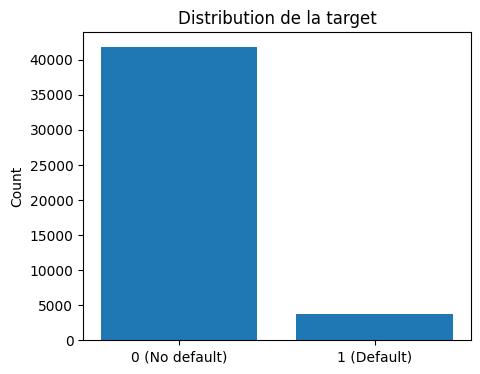

Imbalance ratio (major/minor) = 11.31


In [ ]:
y = train_df[TARGET].astype(int)
dist = y.value_counts().sort_index()
pct = (dist / dist.sum() * 100).round(2)
display(pd.DataFrame({"count": dist, "percent_%": pct}))

plt.figure(figsize=(5,4))
plt.bar(["0 (No default)", "1 (Default)"], dist.values)
plt.title("Distribution de la target")
plt.ylabel("Count")
plt.show()

imb_ratio = dist.max() / max(dist.min(), 1)
print("Imbalance ratio (major/minor) =", round(imb_ratio, 2))

In [ ]:
X_safe = train_df.drop(columns=[TARGET] + DROP_COLS_SENSITIVE, errors="ignore").copy()

num_cols = X_safe.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_safe.columns if c not in num_cols]

print("Nb features total (safe):", X_safe.shape[1])
print("Num cols:", len(num_cols), "| Cat cols:", len(cat_cols))
print("Exemples num:", num_cols[:8])
print("Exemples cat:", cat_cols[:8])

display(X_safe[num_cols].describe().T)

Nb features total (safe): 16
Num cols: 12 | Cat cols: 4
Exemples num: ['age', 'no_of_children', 'net_yearly_income', 'no_of_days_employed', 'total_family_members', 'migrant_worker', 'yearly_debt_payments', 'credit_limit']
Exemples cat: ['gender', 'owns_car', 'owns_house', 'occupation_type']


,count,mean,std,min,25%,50%,75%,max
age,45528.0,38.993411,9.543990,23.00,31.000,39.000,47.0000,5.500000e+01
no_of_children,44754.0,0.420655,0.724097,0.00,0.000,0.000,1.0000,9.000000e+00
net_yearly_income,45528.0,200655.622249,669074.034607,27170.61,126345.835,171714.910,240603.7600,1.407590e+08
no_of_days_employed,45065.0,67609.289293,139323.524434,2.00,936.000,2224.000,5817.0000,3.652520e+05
total_family_members,45445.0,2.158081,0.911572,1.00,2.000,2.000,3.0000,1.000000e+01
migrant_worker,45441.0,0.179111,0.383450,0.00,0.000,0.000,0.0000,1.000000e+00
yearly_debt_payments,45433.0,31796.965311,17269.727234,2237.47,19231.140,29081.650,40561.1500,3.281129e+05
credit_limit,45528.0,43548.416028,148784.686878,4003.14,23973.805,35688.045,53435.7625,3.112997e+07
credit_limit_used(%),45528.0,52.235020,29.376910,0.00,27.000,54.000,78.0000,9.900000e+01
credit_score,45520.0,782.791257,100.619746,500.00,704.000,786.000,867.0000,9.490000e+02


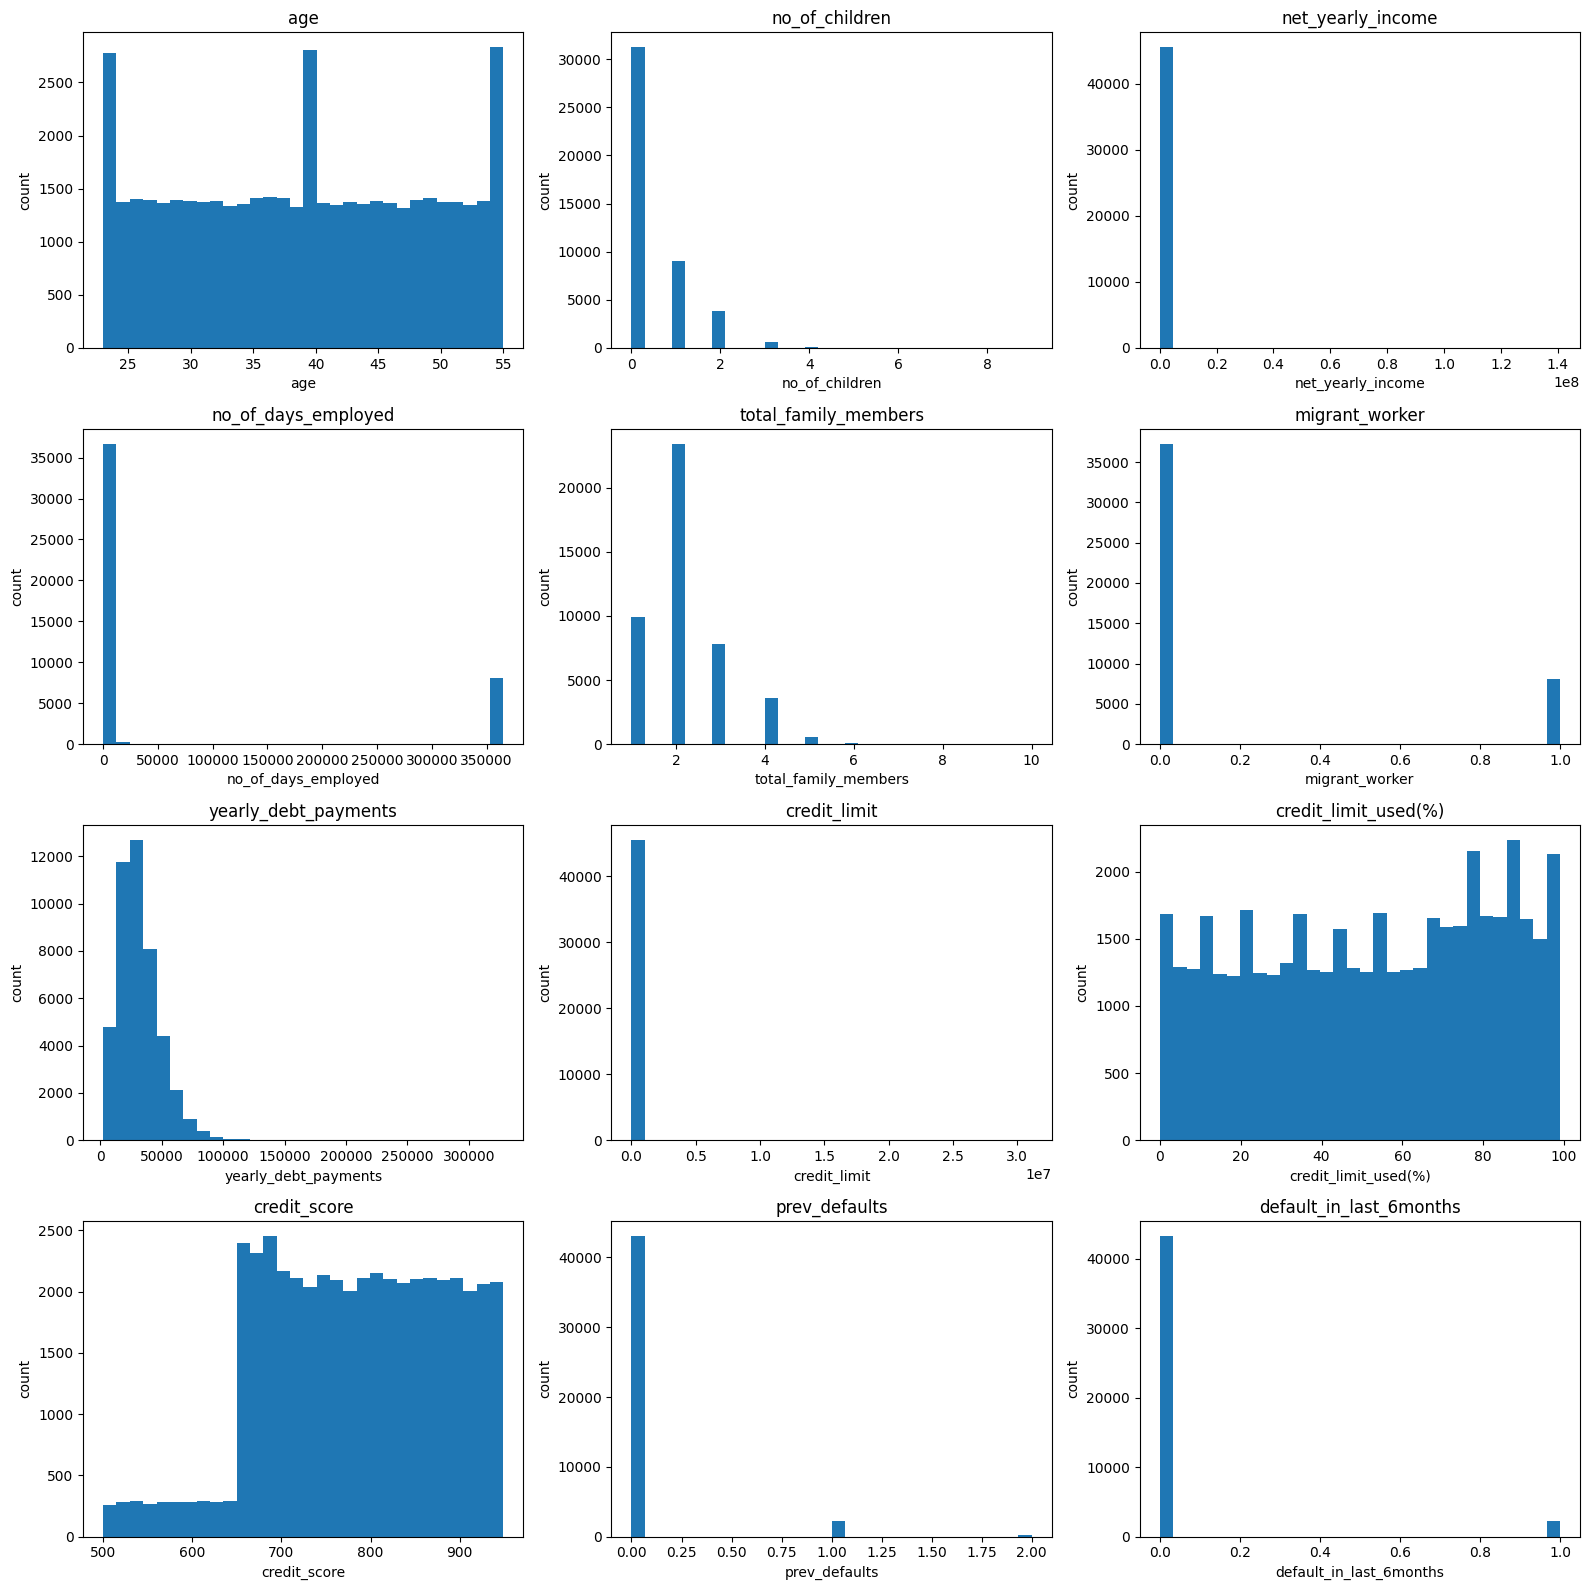

In [ ]:
max_plots = min(12, len(num_cols))
cols_to_plot = num_cols[:max_plots]

n_cols = 3
n_rows = int(np.ceil(max_plots / n_cols))
plt.figure(figsize=(16, 4*n_rows))

for i, col in enumerate(cols_to_plot, start=1):
    plt.subplot(n_rows, n_cols, i)
    series = X_safe[col].dropna()
    plt.hist(series, bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("count")

plt.tight_layout()
plt.show()

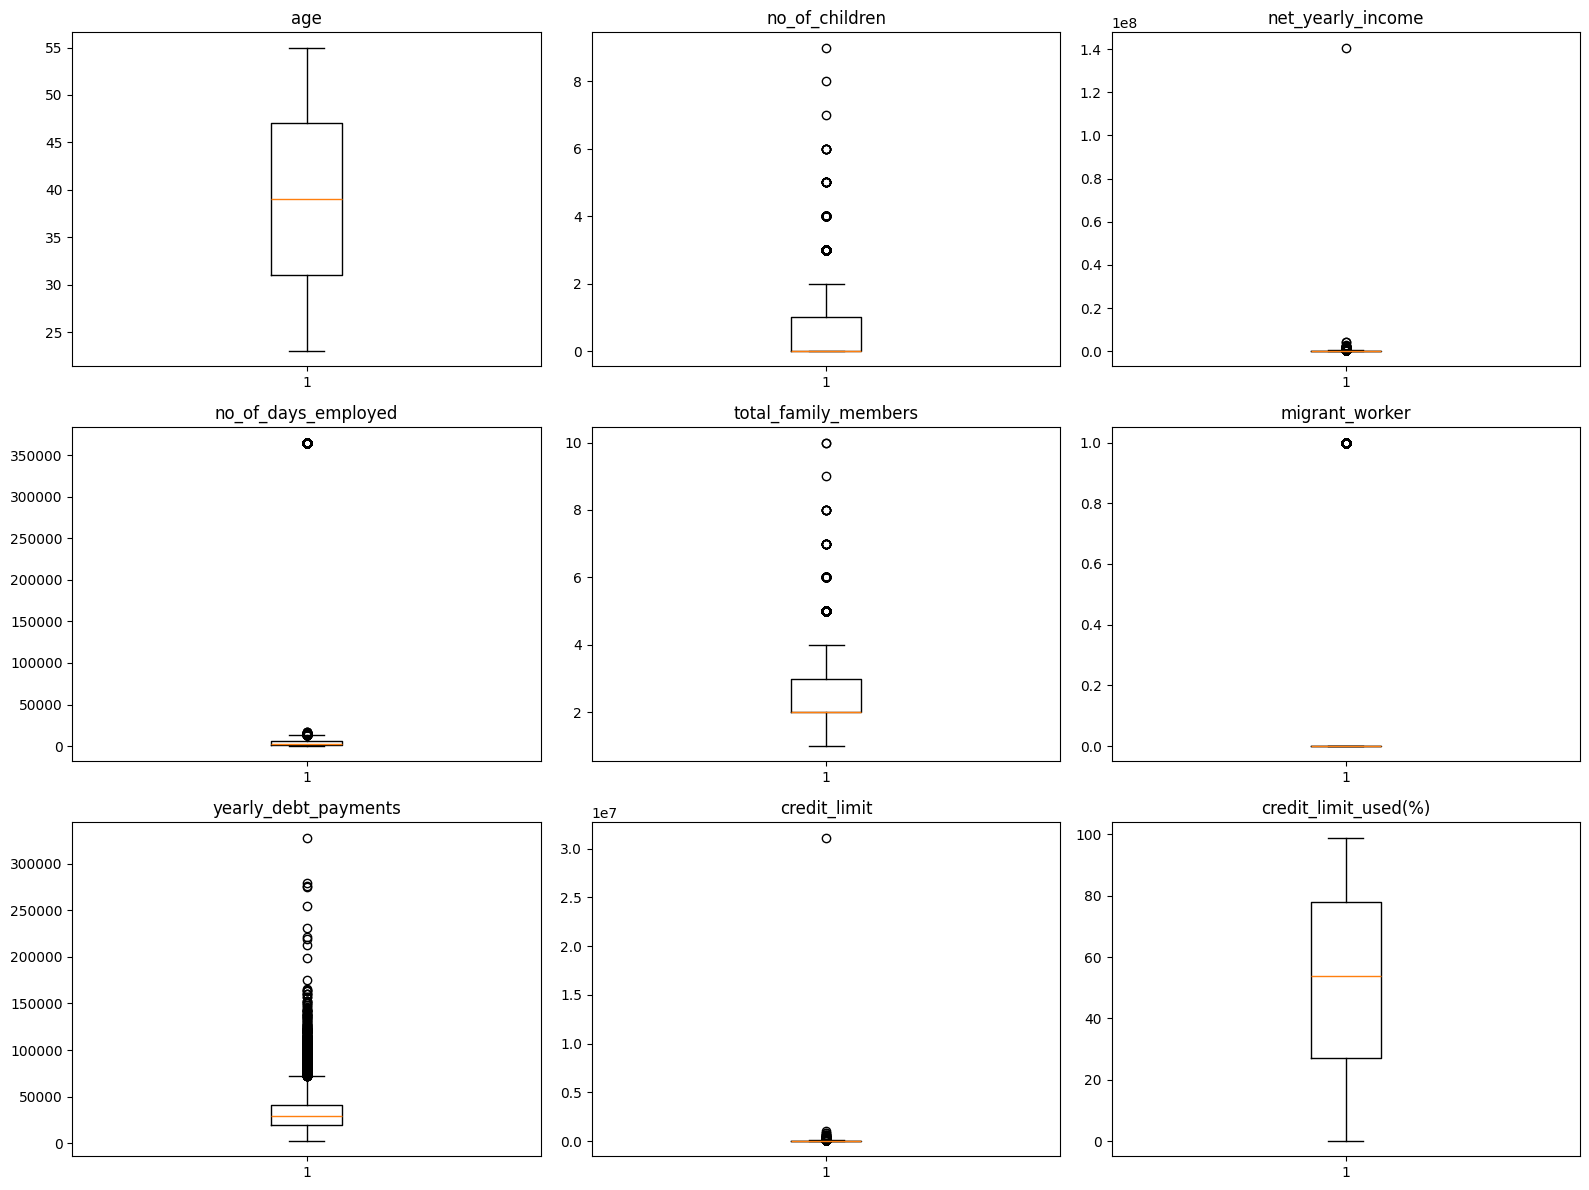

In [ ]:
max_plots = min(9, len(num_cols))
cols_to_plot = num_cols[:max_plots]

n_cols = 3
n_rows = int(np.ceil(max_plots / n_cols))
plt.figure(figsize=(16, 4*n_rows))

for i, col in enumerate(cols_to_plot, start=1):
    plt.subplot(n_rows, n_cols, i)
    data = X_safe[col].dropna().values
    plt.boxplot(data, vert=True)
    plt.title(col)

plt.tight_layout()
plt.show()

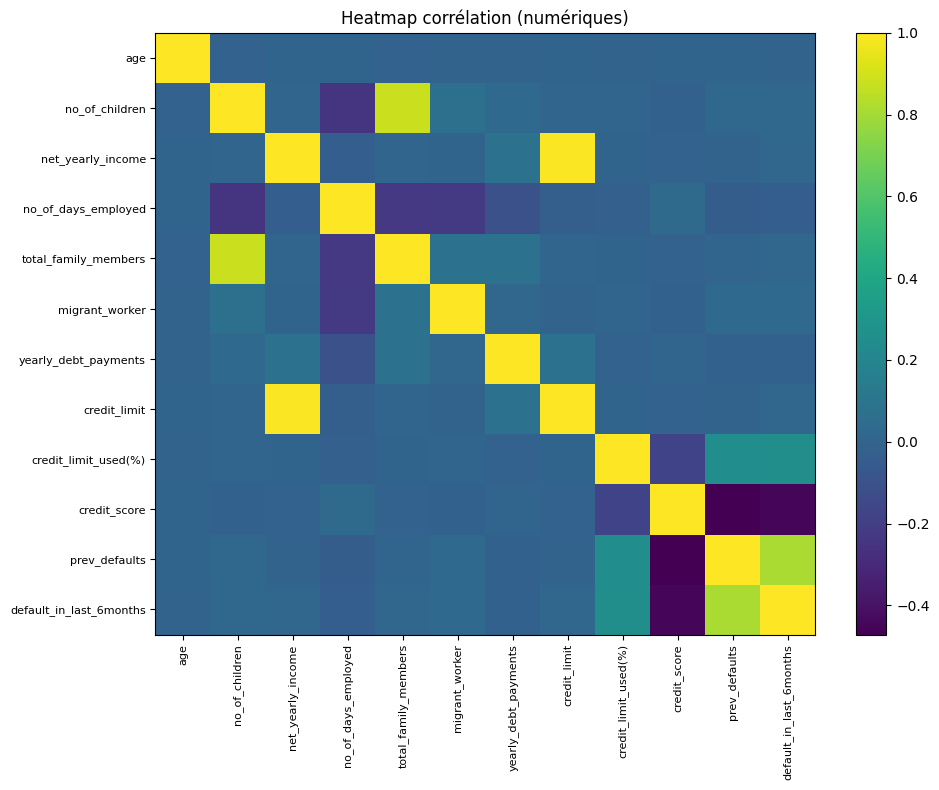

Top 10 corrélations absolues (numériques):


credit_limit             net_yearly_income          0.993378
net_yearly_income        credit_limit               0.993378
total_family_members     no_of_children             0.880278
no_of_children           total_family_members       0.880278
prev_defaults            default_in_last_6months    0.811353
default_in_last_6months  prev_defaults              0.811353
credit_score             prev_defaults              0.471421
prev_defaults            credit_score               0.471421
credit_score             default_in_last_6months    0.450712
default_in_last_6months  credit_score               0.450712
dtype: float64

In [ ]:
corr = X_safe[num_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr.values,aspect="auto")
plt.colorbar()
plt.title("Heatmap corrélation (numériques)")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=8)
plt.yticks(range(len(corr.index)), corr.index, fontsize=8)
plt.tight_layout()
plt.show()

corr_abs = corr.abs().where(~np.eye(len(corr), dtype=bool))
top_pairs = corr_abs.stack().sort_values(ascending=False).head(10)
print("Top 10 corrélations absolues (numériques):")
display(top_pairs)